## Model Training for Tomato Disease Classification

In [1]:
# import modules
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
print("Tensorflow version", tf.__version__)

Tensorflow version 2.19.0


### Load the dataset for tomato leaves
We have a bunch of different categories for tomato plant diseases and we have collected the images of different disease categories and organized them into separate folders under the `datasets` directory.

First thing we do is load the dataset, but loading this big chunk of data and handling that might not be a good idea so we will use `tf.keras.utils.image_dataset_from_directory` to load the dataset off the disk and create different batches of dataset and use them chuck wise instead of loading all at once.

In [3]:
# define some constant parameters for data loading

BATCH_SIZE = 32 # this is also the default value used by keras
IMAGE_SIZE = 256 # check the tomato leaf image info its 256x256 with 3 color channels RGB
DATA_DIR = 'datasets'
TEST_SPLIT=0.2

We can follow two approaches here - 
1. load the dataset and split it into train, val, test later
2. or load the dataset and split it together

So lets follow the second approach.

First we split the whole data into `train_val_ds` and `test_ds` then we keep aside `test_ds` until final model training and we split `train_val_ds` into `train_ds` and `val_ds` which we will use during training the models.

In [4]:
# train the model for selected class, its taking quite longer to train on all the classes
class_names = ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight',
                'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']

In [5]:
help(tf.keras.utils.image_dataset_from_directory)

Help on function image_dataset_from_directory in module keras.src.utils.image_dataset_utils:

image_dataset_from_directory(directory, labels='inferred', label_mode='int', class_names=None, color_mode='rgb', batch_size=32, image_size=(256, 256), shuffle=True, seed=None, validation_split=None, subset=None, interpolation='bilinear', follow_links=False, crop_to_aspect_ratio=False, pad_to_aspect_ratio=False, data_format=None, verbose=True)
    Generates a `tf.data.Dataset` from image files in a directory.

    If your directory structure is:

    ```
    main_directory/
    ...class_a/
    ......a_image_1.jpg
    ......a_image_2.jpg
    ...class_b/
    ......b_image_1.jpg
    ......b_image_2.jpg
    ```

    Then calling `image_dataset_from_directory(main_directory,
    labels='inferred')` will return a `tf.data.Dataset` that yields batches of
    images from the subdirectories `class_a` and `class_b`, together with labels
    0 and 1 (0 corresponding to `class_a` and 1 corresponding to `cl

In [6]:
train_val_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=TEST_SPLIT,
    subset="both", # when we pass both it returns a tuple, else it takes training, validation
    label_mode='int',
    labels="inferred",
    class_names=class_names,
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 7000 files belonging to 5 classes.
Using 5600 files for training.
Using 1400 files for validation.


In [7]:
print("Length of train_val_ds", len(train_val_ds))

len_train_val_ds = len(train_val_ds)
train_size = int(len_train_val_ds*0.8)

print("Training data size", train_size)

Length of train_val_ds 175
Training data size 140


In [8]:
# further split the data into train_ds and val_ds
train_val_ds = train_val_ds.shuffle(10000, seed=123)

train_ds = train_val_ds.take(train_size)
val_ds = train_val_ds.skip(train_size)

print(f"Length of train_ds is {len(train_ds)} and val_ds is {len(val_ds)}")

Length of train_ds is 140 and val_ds is 35


In [9]:
# print the class names - only available on raw dataset loaded before you apply any transformation on it
class_names = test_ds.class_names
print(class_names)

['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


### Visualize the Data
Let's display some of these images

2025-05-02 07:03:34.180620: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


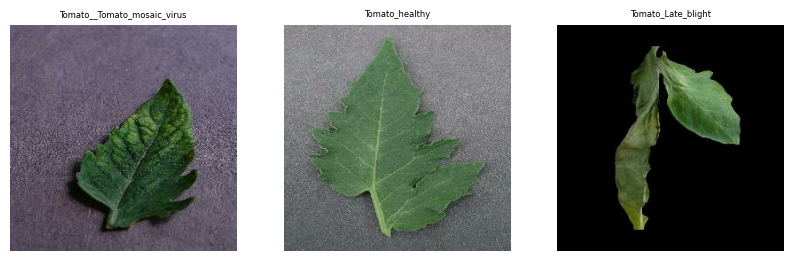

In [10]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(3):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=6)
        plt.axis("off")

In [11]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 256, 256, 3)
(32,)


### Caching and prefetching datasets for performance

In [12]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

### Standardization and Normalization
The image size if 256x256 pixels; first thing we need to do with an incoming image is resize it to 256x256 pixels which is our training size. Because a user can click a picture in any size and upload it, but we need to make sure we resize it.

Next, we need to standardize the RGB channel values which range from 0-255, generally we feed smaller values to neural network in the range 0-1 so we will standardize these values 0-1.

In [13]:
resizing_rescaling = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1.0/255)
])

In [14]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

In [15]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

### Training a model

For our Neural Network Architechture we are going to use - 
1. Convolution blocks
2. Max pooling layer
3. Dense Layer

In [16]:
num_classes = 10 

# define the model
model = tf.keras.Sequential(
    [
        resizing_rescaling,
        tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64,  kernel_size=(3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64,  kernel_size=(3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(68, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ]
)

In [17]:
model.compile(
    optimizer="adam",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    verbose=1,
    epochs=10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 118s 824ms/step - accuracy: 0.3152 - loss: 1.6278 - val_accuracy: 0.5616 - val_loss: 1.1203
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 136s 972ms/step - accuracy: 0.6045 - loss: 1.0075 - val_accuracy: 0.6268 - val_loss: 0.9742
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.7397 - loss: 0.6671 - val_accuracy: 0.7009 - val_loss: 0.7628
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.7992 - loss: 0.5024 - val_accuracy: 0.7750 - val_loss: 0.6175
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.8297 - loss: 0.4292 - val_accuracy: 0.8527 - val_loss: 0.4074
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8497 - loss: 0.3948 - val_accuracy: 0.7884 - val_loss: 0.5424
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.8658 - loss: 0.3534 - val_accuracy: 0.7982 - val_loss: 0.5839
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.8723 - loss: 0.3410 - va

In [19]:
model.save("tomato_model_2.keras")